# Projet pratique - S6 : Structures de donnees Python
## Digitaliser les recoltes du reseau cooperatif AgriSuds

**Akieni Academy** a ete sollicitee par **AgriSuds**, un reseau de cooperatives agricoles
actif dans plusieurs pays d'Afrique (Congo-Brazzaville, Cote d'Ivoire, Cameroun, Senegal,
Togo). Chaque antenne locale enregistre ses recoltes : identite du producteur, culture,
quantite recoltee (kg), prix de vente au kg (FCFA) et anciennete de la recolte (en jours).

**Le besoin exprime par AgriSuds** : des reponses claires, calculees automatiquement en
Python, a des questions concretes que se posent les responsables de la cooperative :
- Quel est le chiffre d'affaires total genere par les recoltes ?
- Quelle quantite a ete recoltee pour telle culture (cacao, cafe, manioc...) ?
- Quelles sont les cultures et antennes actives dans les donnees ?
- Quelle fourchette de prix a ete pratiquee pour une culture ?
- Quelle est la fiche complete d'un producteur donne ?
- Qui sont les producteurs les plus productifs ?
- Quelles recoltes sont recentes, pour anticiper les livraisons ?

**Notions mobilisees dans ce projet** : variables, structures conditionnelles, boucles,
fonctions, et les structures de donnees vues en cours : listes, tuples, dictionnaires,
sets.

**Consigne generale** : completez chaque fonction a l'endroit indique par `# TODO`, puis
executez immediatement la cellule de test juste en dessous pour verifier votre travail
avant de passer a la fonction suivante.


---
## 1. Les donnees de recoltes *(fournies - ne pas modifier)*

Les recoltes du mois sont deja chargees ci-dessous sous forme de **7 listes paralleles** :
la recolte d'indice `i` est decrite par l'element d'indice `i` dans chacune des listes
`IDS`, `AGRICULTEURS`, `ANTENNES`, `CULTURES`, `QUANTITES_KG`, `PRIX_KG_FCFA` et
`JOURS_ECOULE` (anciennete de la recolte, en nombre de jours).

Attention : environ 8% des recoltes ont une **quantite manquante** (valeur `None`), pour
simuler un oubli de saisie sur le terrain. Vos fonctions doivent gerer ce cas sans planter.


In [220]:
# Donnees de recoltes AgriSuds (fournies - ne pas modifier)
# 7 listes paralleles : la recolte d'indice i est decrite par l'element d'indice i
# dans CHACUNE des listes ci-dessous.

IDS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]

AGRICULTEURS = ['Fatou Kouassi', 'Nadege Diop', 'Aminata Mokoko', 'Herve Bationo', 'Serge Ngoma', 'Olivier Diallo', 'Serge Ngoma', 'Olivier Diallo', 'Paul Kouassi', 'Herve Samba', 'Serge Bikindou', 'Aminata Mokoko', 'Olivier Diallo', 'Sandra Loubota', 'Serge Mokoko', 'Prisca Mabiala', 'Olivier Diallo', 'Moise Ngoma', 'Herve Samba', 'Olivier Diallo', 'Serge Bikindou', 'Sandra Loubota', 'Paul Kouassi', 'Aminata Ngoma', 'Aminata Mokoko', 'Larissa Diop', 'Aminata Bationo', 'Serge Nzila', 'Grace Bikindou', 'Aminata Mokoko', 'Herve Bationo', 'Nadege Diop', 'Blaise Malonga', 'Moise Ngoma', 'Aminata Bationo', 'Nadege Diop', 'Paul Kouassi', 'Blaise Malonga', 'Chantal Kouassi', 'Serge Mokoko', 'Serge Nzila', 'Fatou Kouassi', 'Larissa Diop', 'Herve Samba', 'Marie Bikindou', 'Blaise Malonga', 'Grace Kabila', 'Larissa Diop', 'Serge Bikindou', 'Larissa Diop']

ANTENNES = ['Kaolack', 'Divo', 'Divo', 'Kaolack', 'Kpalime', 'Owando', 'Divo', 'Bafoussam', 'Bafoussam', 'Owando', 'Kpalime', 'Kpalime', 'Divo', 'Bafoussam', 'Divo', 'Owando', 'Kaolack', 'Kaolack', 'Bafoussam', 'Bafoussam', 'Bafoussam', 'Kpalime', 'Divo', 'Bafoussam', 'Owando', 'Divo', 'Owando', 'Kpalime', 'Bafoussam', 'Kpalime', 'Kpalime', 'Divo', 'Kaolack', 'Divo', 'Kpalime', 'Kaolack', 'Divo', 'Owando', 'Divo', 'Bafoussam', 'Owando', 'Kaolack', 'Owando', 'Bafoussam', 'Owando', 'Kpalime', 'Kaolack', 'Kaolack', 'Owando', 'Divo']

CULTURES = ['Mais', 'Manioc', 'Riz', 'Huile de palme', 'Cafe', 'Cafe', 'Arachide', 'Banane plantain', 'Cafe', 'Arachide', 'Mais', 'Banane plantain', 'Cafe', 'Arachide', 'Arachide', 'Cacao', 'Mais', 'Banane plantain', 'Mais', 'Cacao', 'Banane plantain', 'Arachide', 'Arachide', 'Mais', 'Riz', 'Cacao', 'Banane plantain', 'Manioc', 'Huile de palme', 'Banane plantain', 'Cacao', 'Cafe', 'Huile de palme', 'Huile de palme', 'Cafe', 'Arachide', 'Mais', 'Huile de palme', 'Cafe', 'Manioc', 'Mais', 'Huile de palme', 'Huile de palme', 'Banane plantain', 'Manioc', 'Arachide', 'Banane plantain', 'Banane plantain', 'Riz', 'Cacao']

QUANTITES_KG = [284.9, 138.2, 20.9, 172.8, 84.7, None, 274.1, 189.0, 70.9, 259.5, 153.4, 54.4, 70.2, 150.9, None, 313.3, 264.8, 80.6, 209.0, None, 271.6, 28.8, 308.3, 81.4, 168.3, 58.9, 86.0, 283.1, 211.2, 57.5, 287.3, 125.0, 206.0, 36.4, None, 86.6, 165.7, 29.3, 213.7, None, 172.5, 182.5, 265.1, 79.3, 124.7, 85.6, None, 119.9, 270.9, 128.5]

PRIX_KG_FCFA = [222, 165, 337, 767, 1601, 1697, 669, 226, 1706, 707, 175, 294, 2141, 622, 583, 1285, 235, 297, 228, 1714, 227, 636, 604, 172, 344, 1323, 214, 162, 632, 277, 1709, 1550, 732, 660, 1945, 680, 222, 818, 1908, 128, 217, 783, 599, 231, 167, 696, 215, 239, 298, 1748]

JOURS_ECOULE = [20, 53, 70, 37, 112, 99, 86, 89, 114, 10, 43, 67, 119, 86, 32, 65, 55, 29, 51, 80, 111, 23, 70, 23, 25, 75, 74, 49, 5, 67, 87, 13, 87, 119, 94, 96, 48, 80, 88, 34, 59, 39, 57, 74, 77, 114, 62, 40, 15, 50]

# Quelques constantes utiles (dictionnaires et listes deja construits)
ANTENNES_DISPONIBLES = ["Owando", "Divo", "Bafoussam", "Kaolack", "Kpalime"]
PAYS_ANTENNE = {
    "Owando": "Congo-Brazzaville",
    "Divo": "Cote d'Ivoire",
    "Bafoussam": "Cameroun",
    "Kaolack": "Senegal",
    "Kpalime": "Togo",
}
CULTURES_DISPONIBLES = ["Cacao", "Cafe", "Manioc", "Mais", "Arachide", "Riz", "Banane plantain", "Huile de palme"]
PRIX_MOYEN_KG = {
    "Cacao": 1500, "Cafe": 1800, "Manioc": 150, "Mais": 200,
    "Arachide": 600, "Riz": 350, "Banane plantain": 250, "Huile de palme": 700,
}

print("Nombre de recoltes chargees :", len(IDS))



Nombre de recoltes chargees : 50


---
## 2. Variables mises a votre disposition *(fourni)*

Executez la cellule ci-dessous pour verifier que tout est bien charge : `ANTENNES_DISPONIBLES`,
`PAYS_ANTENNE`, `CULTURES_DISPONIBLES`, `PRIX_MOYEN_KG`.


In [221]:
print("Antennes disponibles :", ANTENNES_DISPONIBLES)
print("Pays de l'antenne Owando :", PAYS_ANTENNE["Owando"])
print("Cultures disponibles :", CULTURES_DISPONIBLES)
print("Prix moyen du cacao (FCFA/kg) :", PRIX_MOYEN_KG["Cacao"])


Antennes disponibles : ['Owando', 'Divo', 'Bafoussam', 'Kaolack', 'Kpalime']
Pays de l'antenne Owando : Congo-Brazzaville
Cultures disponibles : ['Cacao', 'Cafe', 'Manioc', 'Mais', 'Arachide', 'Riz', 'Banane plantain', 'Huile de palme']
Prix moyen du cacao (FCFA/kg) : 1500


---
## 3. A vous de jouer - Niveau Debutant

Ces 3 fonctions ne manipulent que des **variables**, des **boucles** et des **conditions**.
Completez chaque fonction puis executez tout de suite la cellule de test juste en dessous.


In [222]:
def chiffre_affaires_total(quantites, prix):
    """
    Calcule le chiffre d'affaires total (en FCFA) genere par toutes les recoltes.
    """
    total = 0
    # Regle de calcul : CA total = somme, pour TOUTES les recoltes, de (quantite * prix).
    # Une recolte sans quantite renseignee (None) ne compte pas dans la somme.
    # TODO : parcourez les deux listes avec for i in range(len(quantites))
    # Si quantites[i] is None : ne rien faire (continue ou if/else)
    # Sinon : total += quantites[i] * prix[i]
    
    
    for i in range(len(quantites)) :
        if quantites[i] is None :
            continue 
        total_chiffre_affaires = quantites[i] * prix[i]
        total += total_chiffre_affaires
    return total




In [223]:
# Test de chiffre_affaires_total
resultat = chiffre_affaires_total(QUANTITES_KG, PRIX_KG_FCFA)
print("Chiffre d'affaires total (FCFA) :", resultat)


Chiffre d'affaires total (FCFA) : 4503616.6


In [224]:
def quantite_totale_culture(cultures, quantites, culture_cible):
    """
    Calcule la quantite totale (en kg) recoltee pour une culture donnee.
    """
    total = 0
    # Regle de calcul : quantite totale = somme des quantites[i] pour toutes les
    # recoltes ou cultures[i] == culture_cible, en ignorant les quantites manquantes (None).
    # TODO : parcourez les listes avec l'index i
    # Condition : cultures[i] == culture_cible ET quantites[i] is not None
    
    for i in range(len(cultures)) :
        if cultures[i] == culture_cible and quantites[i] is not None :
            total += quantites[i]
    return total


In [225]:
# Test de quantite_totale_culture
resultat = quantite_totale_culture(CULTURES, QUANTITES_KG, "Cacao")
print("Quantite totale de Cacao (kg) :", resultat)


Quantite totale de Cacao (kg) : 788.0


In [226]:
def nombre_recoltes_antenne(antennes, antenne_cible):
    """
    Compte le nombre de recoltes enregistrees pour une antenne donnee.
    """
    compteur = 0
    # Regle de calcul : on parcourt la liste antennes, et on incremente compteur
    # de 1 chaque fois que antennes[i] correspond a l'antenne recherchee.
    # TODO : parcourez la liste avec l'index i
    # Si antennes[i] == antenne_cible : compteur += 1
    
    for i in range(len(antennes)) :
        if antennes[i] == antenne_cible:
            compteur += 1
    return compteur 



In [227]:
# Test de nombre_recoltes_antenne
resultat = nombre_recoltes_antenne(ANTENNES, "Kpalime")
print("Nombre de recoltes pour Owando :", resultat)


Nombre de recoltes pour Owando : 9


---
## 4. A vous de jouer - Niveau Intermediaire

Ces fonctions manipulent des **tuples**, des **sets** et des **dictionnaires**.


In [228]:
def cultures_et_antennes_uniques(cultures, antennes):
    """
    Renvoie un tuple (cultures_uniques, antennes_uniques) : deux sets contenant
    respectivement les cultures et les antennes distinctes presentes dans les donnees.
    """
    cultures_uniques = set()
    antennes_uniques = set()
    # Regle de calcul : un set ne garde jamais de doublon automatiquement. Il suffit
    # d'ajouter chaque valeur avec .add() sans se soucier de verifier si elle y est deja.
    # TODO : parcourez "cultures" et ajoutez chaque valeur a cultures_uniques avec .add()
    # Faites de meme pour "antennes" -> antennes_uniques
    
    for culture in cultures :
        cultures_uniques.add(culture)
        
    for antenne in antennes :
        antennes_uniques.add(antenne)

    return (cultures_uniques, antennes_uniques)


In [229]:
# Test de cultures_et_antennes_uniques
cultures_uniques, antennes_uniques = cultures_et_antennes_uniques(CULTURES, ANTENNES)
print("Cultures uniques :", cultures_uniques)
print("Antennes uniques :", antennes_uniques)


Cultures uniques : {'Banane plantain', 'Huile de palme', 'Cacao', 'Riz', 'Cafe', 'Arachide', 'Manioc', 'Mais'}
Antennes uniques : {'Kaolack', 'Divo', 'Owando', 'Bafoussam', 'Kpalime'}


In [230]:
def fourchette_prix_culture(cultures, prix, culture_cible):
    """
    Renvoie un tuple (prix_min, prix_max) parmi les recoltes de la culture demandee.
    """
    prix_de_la_culture = []
    # Regle de calcul : on construit d'abord la liste de tous les prix observes pour
    # cette culture, puis on prend min() et max() de cette liste.
    # TODO : parcourez les listes avec l'index i
    # Si cultures[i] == culture_cible : prix_de_la_culture.append(prix[i])
    
    for i in range(len(cultures)) :
        if cultures[i] == culture_cible :
            prix_de_la_culture.append(prix[i])

    prix_min = min(prix_de_la_culture)
    prix_max = max(prix_de_la_culture)
    return (prix_min, prix_max)


In [231]:
# Test de fourchette_prix_culture
prix_min, prix_max = fourchette_prix_culture(CULTURES, PRIX_KG_FCFA, "Arachide")
print("Prix du Cafe (FCFA/kg) : entre", prix_min, "et", prix_max)


Prix du Cafe (FCFA/kg) : entre 583 et 707


In [232]:
def fiche_producteur(agriculteurs, antennes, cultures, quantites, nom_cible):
    """
    Construit une fiche resumee (dictionnaire) pour un producteur donne :
    {"antenne": ..., "cultures": {set des cultures produites}, "quantite_totale": ...}
    """
    antenne_producteur = None
    cultures_produites = set()
    quantite_totale = 0
    # Regle de calcul : on parcourt toutes les recoltes ; des qu'on rencontre le
    # producteur cible, on note son antenne, on ajoute sa culture au set (pas de
    # doublon), et on cumule sa quantite (en ignorant les quantites manquantes None).
    # TODO : parcourez les listes avec l'index i
    # Si agriculteurs[i] == nom_cible :
    #   - antenne_producteur = antennes[i]
    #   - cultures_produites.add(cultures[i])
    #   - si quantites[i] is not None : quantite_totale += quantites[i]
    
    for i in range(len(agriculteurs)) :
        if agriculteurs[i] == nom_cible :
            antenne_producteur = antennes[i]
            cultures_produites.add(cultures[i])
            
            if quantites[i] is not None :
                quantite_totale += quantites [i] 


    fiche = {
        "antenne": antenne_producteur,
        "cultures": cultures_produites,
        "quantite_totale": quantite_totale,
    }
    return fiche


In [233]:
# Test de fiche_producteur
fiche = fiche_producteur(AGRICULTEURS, ANTENNES, CULTURES, QUANTITES_KG, "Olivier Diallo")
print("Fiche d'Olivier Diallo :", fiche)


Fiche d'Olivier Diallo : {'antenne': 'Bafoussam', 'cultures': {'Cacao', 'Banane plantain', 'Cafe', 'Mais'}, 'quantite_totale': 524.0}


---
## 5. A vous de jouer - Niveau Avance

Ces fonctions combinent boucles, dictionnaires et le tri avec `sorted()` et son
parametre `key`.


In [234]:
def cle_de_tri(paire):
    """Fonction utilitaire : renvoie la quantite d'une paire (nom, quantite), pour trier avec sorted()."""
    return paire[1]


def top_n_producteurs(agriculteurs, quantites, n):
    """
    Renvoie les n producteurs ayant recolte le plus de quantite au total, sous forme
    de liste de tuples (nom, quantite_totale), du plus grand au plus petit.
    """
    noms_uniques = []
    totaux = []
    # Regle de calcul : on cumule d'abord la quantite totale par producteur (une seule
    # case par nom), puis on trie la liste de tuples (nom, quantite) du plus grand au
    # plus petit avec sorted(key=...), et on garde seulement les n premiers [:n].
    # TODO :
    # 1) parcourez agriculteurs/quantites avec l'index i (en ignorant quantites[i] is None)
    #    - si agriculteurs[i] n'est pas encore dans noms_uniques : ajoutez-le, et ajoutez
    #      sa quantite dans totaux a la meme position
    #    - sinon : retrouvez sa position avec noms_uniques.index(agriculteurs[i])
    #      et ajoutez la quantite a totaux a cette position
    
    for i in range(len(agriculteurs)) :
        if quantites[i] == None :
            continue
        if agriculteurs[i]  not in noms_uniques :
            noms_uniques.append(agriculteurs[i])
            totaux.append(quantites[i])
        else :
            index_existant = noms_uniques.index(agriculteurs[i])
            totaux[index_existant] += quantites[i]

    paires = []
    for i in range(len(noms_uniques)):
        paires.append((noms_uniques[i], totaux[i]))

    paires_triees = sorted(paires, key=cle_de_tri, reverse=True)
    return paires_triees[:n]


In [235]:
# Test de top_n_producteurs
top5 = top_n_producteurs(AGRICULTEURS, QUANTITES_KG, 5)
print("Top 5 des producteurs :")
for nom, total in top5:
    print(" -", nom, ":", round(total, 1), "kg")


Top 5 des producteurs :
 - Serge Bikindou : 695.9 kg
 - Larissa Diop : 572.4 kg
 - Herve Samba : 547.8 kg
 - Paul Kouassi : 544.9 kg
 - Olivier Diallo : 524.0 kg


In [236]:
def recoltes_recentes(jours_ecoule, quantites, prix, nb_jours):
    """
    Calcule le chiffre d'affaires total des recoltes dont l'anciennete (en jours)
    est inferieure ou egale a nb_jours.
    """
    total = 0
    # Regle de calcul : pour chaque recolte i, si jours_ecoule[i] <= nb_jours ET
    # que la quantite n'est pas manquante, on ajoute (quantite * prix) au total.
    # TODO : parcourez les listes avec l'index i
    
    for i in range(len(jours_ecoule)):
        if quantites[i] is None:
            continue
        if jours_ecoule[i] <=nb_jours:
            total += quantites[i] * prix[i]

    return total


In [237]:
# Test de recoltes_recentes
resultat = recoltes_recentes(JOURS_ECOULE, QUANTITES_KG, PRIX_KG_FCFA, 30)
print("CA des recoltes des 30 derniers jours (FCFA) :", resultat)


CA des recoltes des 30 derniers jours (FCFA) : 768821.8999999999


In [238]:
def repartition_par_culture_pourcentage(cultures, quantites, cultures_uniques):
    """
    Renvoie un dictionnaire {culture: pourcentage_du_total} donnant, pour chaque
    culture, sa part (en %) dans la quantite totale recoltee toutes cultures confondues.
    """
    quantite_par_culture = {}
    # Etape 1 : pour chaque culture du set cultures_uniques, calculez sa quantite totale
    # avec quantite_totale_culture(...), et stockez-la dans le dictionnaire
    # quantite_par_culture[culture] = ...
    # TODO :
    
    for culture in cultures_uniques :
        quantite_par_culture[culture] = quantite_totale_culture(cultures, quantites,culture)
        
    quantite_totale_generale = sum(quantite_par_culture.values())

    repartition = {}
    # Etape 2 : pour chaque culture, calculez son pourcentage :
    # repartition[culture] = round(quantite_par_culture[culture] / quantite_totale_generale * 100, 1)
    # TODO :
    
    for culture in cultures_uniques :
        repartition[culture] = round((quantite_par_culture[culture] / quantite_totale_generale * 100), 1)
        
    return repartition

In [239]:
# Test de repartition_par_culture_pourcentage
cultures_uniques, _ = cultures_et_antennes_uniques(CULTURES, ANTENNES)
repartition = repartition_par_culture_pourcentage(CULTURES, QUANTITES_KG, cultures_uniques)
print("Repartition (%) par culture :", repartition)
print("Somme des pourcentages (doit etre proche de 100) :", round(sum(repartition.values()), 1))


Repartition (%) par culture : {'Banane plantain': 13.5, 'Huile de palme': 15.9, 'Cacao': 11.4, 'Riz': 6.6, 'Cafe': 8.2, 'Arachide': 17.2, 'Manioc': 7.9, 'Mais': 19.2}
Somme des pourcentages (doit etre proche de 100) : 99.9


---
## 6. Bonus (facultatif)

Cette fonction n'est pas notee mais vous entraine a combiner boucles, dictionnaires
et comparaisons imbriquees.


In [240]:
def producteur_plus_actif_par_antenne(agriculteurs, antennes, quantites):
    """
    Renvoie un dictionnaire {antenne: nom_du_producteur_le_plus_productif} donnant,
    pour chaque antenne, le nom du producteur ayant recolte la plus grande quantite
    totale au sein de cette antenne.
    """
    quantite_par_producteur_et_antenne = {}
    # Etape 1 : construisez un dictionnaire {(antenne, producteur): quantite_totale}
    # en parcourant les 3 listes avec l'index i (ignorez les quantites manquantes).
    # Astuce : cle = (antennes[i], agriculteurs[i])
    # TODO :


    meilleur_par_antenne = {}
    # Etape 2 : pour chaque cle (antenne, producteur) du dictionnaire precedent,
    # si l'antenne n'est pas encore dans meilleur_par_antenne OU si la quantite du
    # producteur actuel depasse celle deja enregistree pour cette antenne, mettez a
    # jour meilleur_par_antenne[antenne] = producteur.
    # TODO :


    return meilleur_par_antenne


In [241]:
# Test de producteur_plus_actif_par_antenne
resultat = producteur_plus_actif_par_antenne(AGRICULTEURS, ANTENNES, QUANTITES_KG)
print("Producteur le plus actif par antenne :", resultat)


Producteur le plus actif par antenne : {}


---
## 7. Verification finale *(fourni - ne pas modifier)*

Executez cette cellule pour verifier d'un seul coup l'ensemble de vos fonctions.


In [242]:
def tester(nom, fonction):
    try:
        resultat = fonction()
        if resultat is None:
            print(f"XX {nom} : la fonction renvoie None (avez-vous oublie un return ?)")
        else:
            print(f"OK {nom} : {resultat}")
    except Exception as erreur:
        print(f"XX {nom} : erreur -> {erreur}")


print("=== Niveau Debutant ===")
tester("chiffre_affaires_total", lambda: round(chiffre_affaires_total(QUANTITES_KG, PRIX_KG_FCFA)))
tester("quantite_totale_culture (Cacao)", lambda: round(quantite_totale_culture(CULTURES, QUANTITES_KG, "Cacao")))
tester("nombre_recoltes_antenne (Owando)", lambda: nombre_recoltes_antenne(ANTENNES, "Owando"))

print()
print("=== Niveau Intermediaire ===")
tester("cultures_et_antennes_uniques", lambda: cultures_et_antennes_uniques(CULTURES, ANTENNES))
tester("fourchette_prix_culture (Cafe)", lambda: fourchette_prix_culture(CULTURES, PRIX_KG_FCFA, "Cafe"))
tester("fiche_producteur (Olivier Diallo)", lambda: fiche_producteur(AGRICULTEURS, ANTENNES, CULTURES, QUANTITES_KG, "Olivier Diallo"))

print()
print("=== Niveau Avance ===")
tester("top_n_producteurs (top 3)", lambda: top_n_producteurs(AGRICULTEURS, QUANTITES_KG, 3))
tester("recoltes_recentes (30 jours)", lambda: round(recoltes_recentes(JOURS_ECOULE, QUANTITES_KG, PRIX_KG_FCFA, 30)))
tester("repartition_par_culture_pourcentage", lambda: repartition_par_culture_pourcentage(CULTURES, QUANTITES_KG, cultures_et_antennes_uniques(CULTURES, ANTENNES)[0]))

print()
print("=== Bonus ===")
tester("producteur_plus_actif_par_antenne", lambda: producteur_plus_actif_par_antenne(AGRICULTEURS, ANTENNES, QUANTITES_KG))


=== Niveau Debutant ===
OK chiffre_affaires_total : 4503617
OK quantite_totale_culture (Cacao) : 788
OK nombre_recoltes_antenne (Owando) : 10

=== Niveau Intermediaire ===
OK cultures_et_antennes_uniques : ({'Banane plantain', 'Huile de palme', 'Cacao', 'Riz', 'Cafe', 'Arachide', 'Manioc', 'Mais'}, {'Kaolack', 'Divo', 'Owando', 'Bafoussam', 'Kpalime'})
OK fourchette_prix_culture (Cafe) : (1550, 2141)
OK fiche_producteur (Olivier Diallo) : {'antenne': 'Bafoussam', 'cultures': {'Cacao', 'Banane plantain', 'Cafe', 'Mais'}, 'quantite_totale': 524.0}

=== Niveau Avance ===
OK top_n_producteurs (top 3) : [('Serge Bikindou', 695.9), ('Larissa Diop', 572.4), ('Herve Samba', 547.8)]
OK recoltes_recentes (30 jours) : 768822
OK repartition_par_culture_pourcentage : {'Banane plantain': 13.5, 'Huile de palme': 15.9, 'Cacao': 11.4, 'Riz': 6.6, 'Cafe': 8.2, 'Arachide': 17.2, 'Manioc': 7.9, 'Mais': 19.2}

=== Bonus ===
OK producteur_plus_actif_par_antenne : {}


---
## 8. Visualisation *(fourni - se met a jour automatiquement)*

Ces graphiques utilisent vos fonctions pour illustrer la production d'AgriSuds.
Executez cette cellule une fois vos fonctions completees.


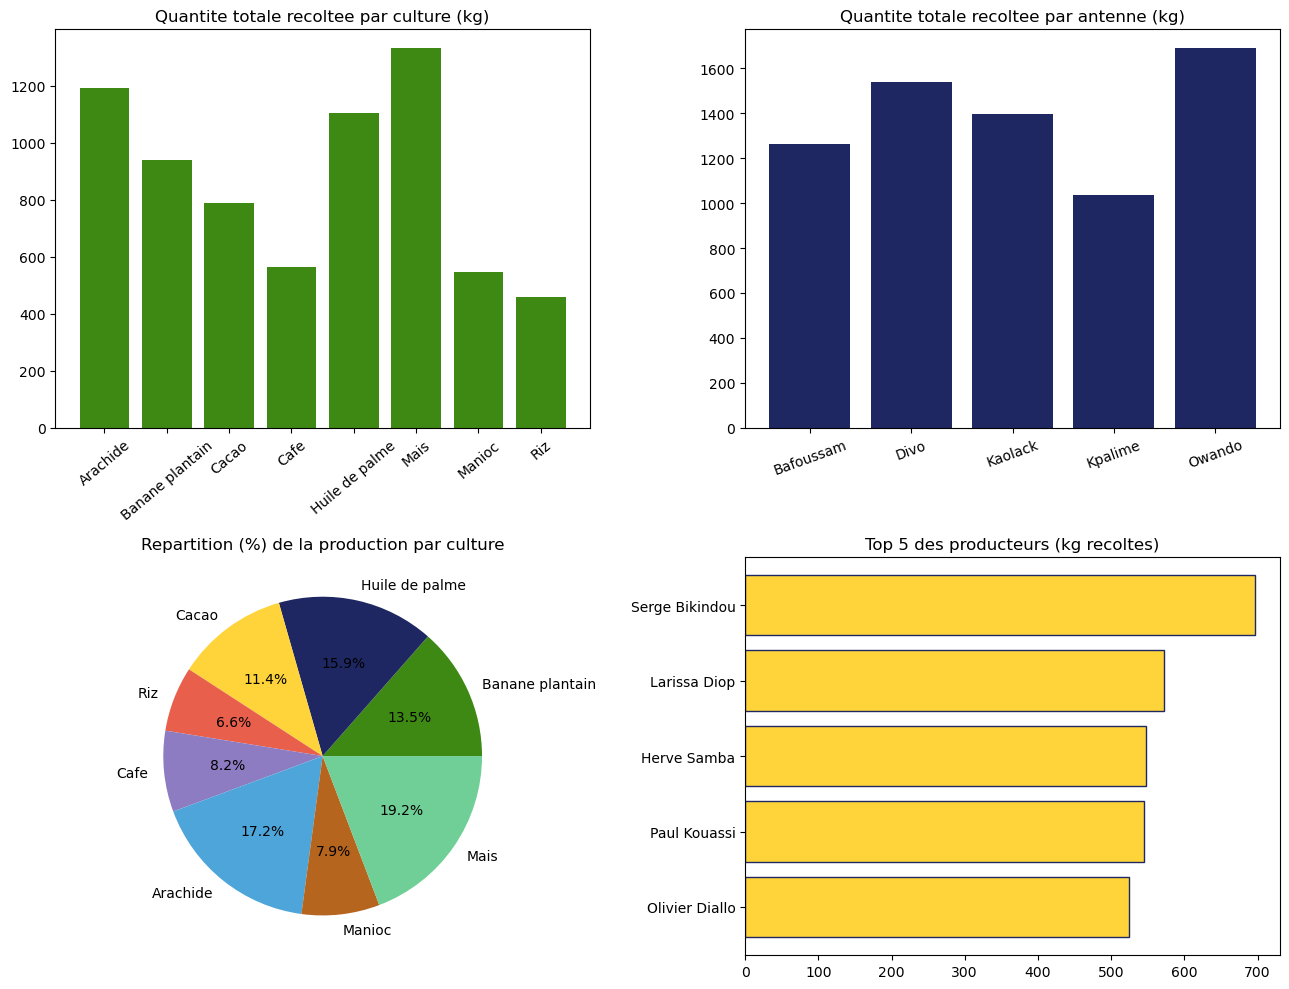

In [243]:
import matplotlib.pyplot as plt

NAVY = "#1E2761"
GREEN = "#3E8914"
YELLOW = "#FFD43B"
CORAL = "#E8604C"
plt.rcParams["font.family"] = "DejaVu Sans"

cultures_uniques, antennes_uniques = cultures_et_antennes_uniques(CULTURES, ANTENNES)

noms_cultures = sorted(cultures_uniques)
totaux_cultures = [quantite_totale_culture(CULTURES, QUANTITES_KG, c) for c in noms_cultures]

noms_antennes = sorted(antennes_uniques)
totaux_antennes = []
for antenne in noms_antennes:
    total_antenne = 0
    for i in range(len(ANTENNES)):
        if ANTENNES[i] == antenne and QUANTITES_KG[i] is not None:
            total_antenne += QUANTITES_KG[i]
    totaux_antennes.append(total_antenne)

repartition_pct = repartition_par_culture_pourcentage(CULTURES, QUANTITES_KG, cultures_uniques)
top5 = top_n_producteurs(AGRICULTEURS, QUANTITES_KG, 5)
noms_top5 = [nom for nom, total in top5][::-1]
totaux_top5 = [total for nom, total in top5][::-1]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].bar(noms_cultures, totaux_cultures, color=GREEN)
axes[0, 0].set_title("Quantite totale recoltee par culture (kg)")
axes[0, 0].tick_params(axis="x", rotation=40)

axes[0, 1].bar(noms_antennes, totaux_antennes, color=NAVY)
axes[0, 1].set_title("Quantite totale recoltee par antenne (kg)")
axes[0, 1].tick_params(axis="x", rotation=20)

axes[1, 0].pie(
    repartition_pct.values(),
    labels=repartition_pct.keys(),
    autopct="%.1f%%",
    colors=[GREEN, NAVY, YELLOW, CORAL, "#8E7CC3", "#4EA5D9", "#B5651D", "#6FCF97"],
)
axes[1, 0].set_title("Repartition (%) de la production par culture")

axes[1, 1].barh(noms_top5, totaux_top5, color=YELLOW, edgecolor=NAVY)
axes[1, 1].set_title("Top 5 des producteurs (kg recoltes)")

plt.tight_layout()
plt.show()


---
## 9. Synthese *(a completer)*

Repondez en 3-4 phrases, en francais, directement dans cette cellule (double-cliquez pour
l'editer) :
- Quelle est la culture la plus rentable pour AgriSuds d'apres vos calculs ?
- Quelle antenne devrait, selon vous, recevoir un accompagnement prioritaire (prix bas,
  faible production...) ?
- Quelle a ete la fonction la plus difficile a ecrire, et pourquoi ?

*(Votre reponse ici)*

1. Culture la plus rentable
Le Café est la culture la plus rentable financièrement, tandis que le Maïs est la plus rentable en volume de production (19,2 % du total).

2. Antenne devant recevoir un accompagnement prioritaire
L'antenne d'Owando doit être accompagnée en priorité. Ses rendements moyens par récolte sont très faibles (environ 115 kg) et elle manque de cultures de rente à haute valeur ajoutée.

3. Pour moi, la fonction top_n_producteurs() a été la plus difficile à écrire, car il fallait regrouper les quantités par producteur, gérer les doublons, puis trier les résultats afin d'obtenir les producteurs les plus performants.


---
## 10. Partagez votre projet sur LinkedIn

C'est l'occasion de montrer ce que vous savez faire ! Publiez un court post presentant ce
projet (le contexte AgriSuds, les notions utilisees, une capture d'ecran de vos graphiques),
en mentionnant Akieni Academy. N'hesitez pas a joindre votre notebook ou un lien vers votre
depot GitHub.
